In [1]:
import dill
from gpcam import GPOptimizer
import numpy as np
import matplotlib.pyplot as plt


In [2]:
with open('dataset.pkl', 'rb') as fin:
    loaded_dict = dill.load(fin)

In [3]:
loaded_dict.keys()

dict_keys(['train', 'test'])

In [4]:
x_train = loaded_dict["train"]["features"]
y_train = loaded_dict["train"]["intensities"][:,0]


x_test = loaded_dict["test"]["features"]
y_test = loaded_dict["test"]["intensities"][:,0]

In [36]:
x_train.shape

(500, 153)

In [5]:
print("y_test: ",  np.min(y_test), np.max(y_test))
print("y_train: ", np.min(y_train), np.max(y_train))

y_test:  0.00688403272316697 0.03614210646837987
y_train:  0.006788552284585955 0.0338475626338495


In [6]:
mi = np.min(y_train)
y_train = y_train - mi
y_test = y_test - mi

ma = np.max(y_train)
y_train = y_train/ma
y_test = y_test/ma

In [7]:
print("y_test: ",  np.min(y_test), np.max(y_test))
print("y_train: ", np.min(y_train), np.max(y_train))

y_test:  0.003528600541875075 1.0847977736404104
y_train:  0.0 1.0


In [8]:
from scipy.stats import wasserstein_distance


def wasserstein_1d(a, b):
    a = a/np.sum(a)
    b = b/np.sum(b)
    a_sorted = np.sort(a)
    b_sorted = np.sort(b)
    return np.mean(np.abs(a_sorted - b_sorted))


def wasserstein_1d_outer_vec(a, b):
    a = a / a.sum(axis=1, keepdims=True)
    b = b / b.sum(axis=1, keepdims=True)

    a_sorted = np.sort(a, axis=1)
    b_sorted = np.sort(b, axis=1)
    s = a_sorted[:, None, :] - b_sorted[None, :, :]
    return np.mean(np.abs(s), axis=2)


def wasserstein_1d_outer(X, Y):
    """
    Compute pairwise 1D Wasserstein distances between two sets of 1D distributions.

    Parameters:
    - X: list of 1D numpy arrays (each array is a sample from a distribution)
    - Y: list of 1D numpy arrays (each array is a sample from a distribution)

    Returns:
    - D: 2D numpy array of shape (len(X), len(Y)) with Wasserstein distances
    """
    n, m = len(X), len(Y)
    D = np.zeros((n, m))

    X = X / X.sum(axis=1, keepdims=True)
    Y = Y / Y.sum(axis=1, keepdims=True)

    for i in range(n):
        for j in range(m):
            D[i, j] = wasserstein_distance(X[i], Y[j])
    
    return D

def l1_dist_ani(x1,x2, hps):
    d = 0.
    for i in range(x1.shape[1]):
        d = d + abs(np.subtract.outer(x1[:,i], x2[:,i])/hps[i])
    #d = abs(np.sum(np.abs(x1[:, np.newaxis, :] - x2[np.newaxis, :, :]), axis=2))
    return d

def l1_dist(x1,x2):
    d = 0.
    for i in range(x1.shape[1]):
        d = d + abs(np.subtract.outer(x1[:,i], x2[:,i]))
    #d = abs(np.sum(np.abs(x1[:, np.newaxis, :] - x2[np.newaxis, :, :]), axis=2))
    return d

def l2_dist(x1,x2):
    d = 0.
    for i in range(x1.shape[1]):
        d = d + abs(np.subtract.outer(x1[:,i], x2[:,i]))
    #d = abs(np.sum(np.abs(x1[:, np.newaxis, :] - x2[np.newaxis, :, :]), axis=2))
    return d

x_train_distr = np.zeros((len(x_train), 400))
for i in range(len(x_train)):
    x_train_distr[i], bin_edges = np.histogram(x_train[i], bins=400, range=(0, 10))

from gpcam.gp_kernels import *
def kernel(x1,x2, hps):
    x1_distr = np.zeros((len(x1), 100))
    x2_distr = np.zeros((len(x2), 100))
    for i in range(len(x1)):
        x1_distr[i], bin_edges = np.histogram(x1[i], bins=40, range=(0, 10))
    for i in range(len(x2)):
        x2_distr[i], bin_edges = np.histogram(x2[i], bins=40, range=(0, 10))
    d = wasserstein_1d_outer_vec(x1_distr, x2_distr)
    #d = l1_dist(x1,x2)
    #print(np.max(d))
    #plt.imshow(d)
    #plt.show()
    k = hps[0] * exponential_kernel(d, hps[1])
    #print(np.min(np.linalg.eig(k)[0]))

    return k

hps_bounds = np.zeros((2,2))
hps_bounds[0] = np.array([0.00001, 10.])
hps_bounds[1:] = np.array([0.0000001, 0.01])

init_hps = np.random.uniform(low = hps_bounds[:,0], high = hps_bounds[:,1], size = len(hps_bounds))



#print(np.min(np.linalg.eig(kernel(x_train, x_train, init_hps))[0]))
#print(kernel(x_train, x_train, init_hps))

my_gp2S = GPOptimizer(x_train,y_train,init_hyperparameters=init_hps, gp_kernel_function= kernel, 
                      compute_device="cpu", noise_variances=np.zeros(y_train.shape) + 0.0001
                      )

In [9]:
my_gp2S.train(hyperparameter_bounds=hps_bounds, info = True, method = "mcmc", max_iter=1000)

Finished  100  out of  1000  iterations. f(x)=  -14.609536392899145
Finished  200  out of  1000  iterations. f(x)=  69.0545417267765
Finished  300  out of  1000  iterations. f(x)=  147.50557276520703
Finished  400  out of  1000  iterations. f(x)=  195.4039717086689
Finished  500  out of  1000  iterations. f(x)=  201.03491753093408
Finished  600  out of  1000  iterations. f(x)=  201.71237847121984
Finished  700  out of  1000  iterations. f(x)=  201.28548895704148
Finished  800  out of  1000  iterations. f(x)=  201.49208816986902
Finished  900  out of  1000  iterations. f(x)=  201.04553900982307


array([2.55752960e-02, 3.07379054e-05])

Text(0, 0.5, 'y test')

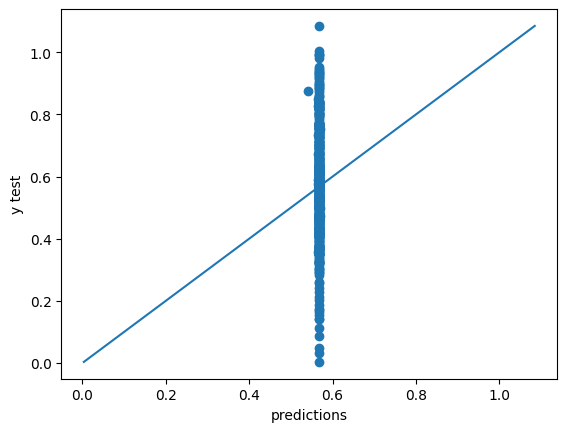

In [10]:
import matplotlib.pyplot as plt
mean = my_gp2S.posterior_mean(x_test)["f(x)"]
plt.plot(np.linspace(np.min(y_test), np.max(y_test),100), np.linspace(np.min(y_test), np.max(y_test),100))
plt.scatter(mean, y_test)
plt.xlabel("predictions")
plt.ylabel("y test")

Text(0, 0.5, 'y diff')

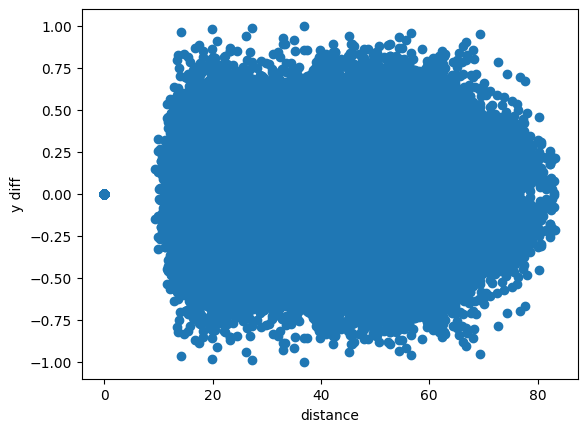

In [11]:
D = l2_dist(x_train,x_train)
y_diff = np.subtract.outer(y_train, y_train)

plt.scatter(D.flatten(), y_diff.flatten())
plt.xlabel("distance")
plt.ylabel("y diff")

In [32]:
bins = 10

x_train_distr = np.zeros((len(x_train), bins))
for i in range(len(x_train)):
    x_train_distr[i], bin_edges = np.histogram(x_train[i], bins=10, range=(0, bins))

In [34]:

for i in range(len(x_train), 10):
    plt.hist(x_train[i], bins=bins)
    plt.show()


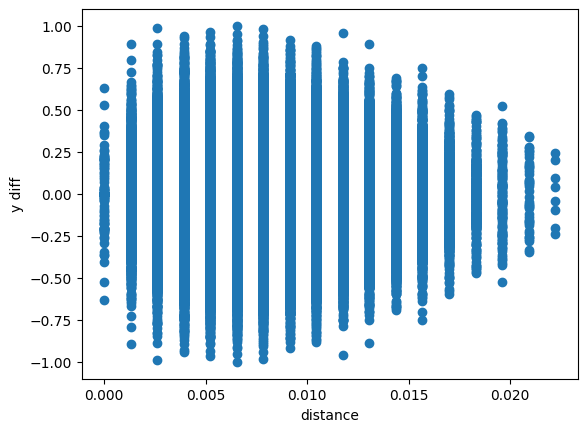

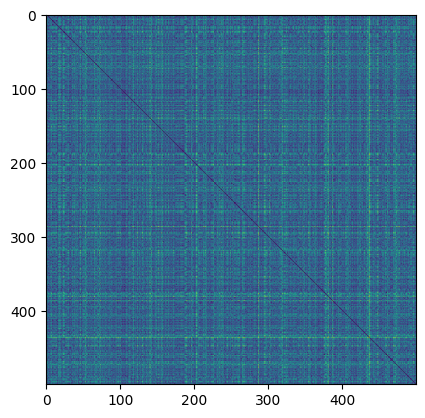

In [35]:
D = wasserstein_1d_outer_vec(x_train_distr,x_train_distr)
y_diff = np.subtract.outer(y_train, y_train)

plt.scatter(D.flatten(), y_diff.flatten())
plt.xlabel("distance")
plt.ylabel("y diff")
plt.show()

plt.imshow(D)